# Run Any Kind of Logistic Regression (Binomial, Multinomial, etc.)

### Authors: Calvin Howard.

#### Last updated: March 16, 2024

Use this to run/test a statistical model on a spreadsheet.

Notes:
- To best use this notebook, you should be familar with GLM design and Contrast Matrix design. See this webpage to get started:
[FSL's GLM page](https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/GLM)

# 00 - Import CSV with All Data
**The CSV is expected to be in this format**
- ID and absolute paths to niftis are critical
```
+-----+----------------------------+--------------+--------------+--------------+
| ID  | Nifti_File_Path            | Covariate_1  | Covariate_2  | Covariate_3  |
+-----+----------------------------+--------------+--------------+--------------+
| 1   | /path/to/file1.nii.gz      | 0.5          | 1.2          | 3.4          |
| 2   | /path/to/file2.nii.gz      | 0.7          | 1.4          | 3.1          |
| 3   | /path/to/file3.nii.gz      | 0.6          | 1.5          | 3.5          |
| 4   | /path/to/file4.nii.gz      | 0.9          | 1.1          | 3.2          |
| ... | ...                        | ...          | ...          | ...          |
+-----+----------------------------+--------------+--------------+--------------+
```

Prep Output Directory

In [24]:
# Specify where you want to save your results to
out_dir = None

Import Data

In [25]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Users/cu135/hires_backdrops/t/master.csv'
sheet = None

In [26]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
# Instantiate the PalmPrepararation class
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=out_dir, sheet=sheet)
# Call the process_nifti_paths method
data_df = cal_palm.read_and_display_data()
data_df

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,002_S_0619,-35472.21632,-23876.106190,-1947.061673,-51088.10268,-81475.108430,-66818.857830,-72864.628840,-30069.234640,-10494.169140,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.485236,0.580121,0.562639,0.325657,-0.243680,-0.233823,-0.233823
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,002_S_0816,-25421.11325,5181.427094,-602.793112,-21580.67530,-6457.362689,-10210.014380,-26903.539720,-5411.426766,1345.683231,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.168095,0.141948,0.143908,0.213945,-0.041915,0.003263,0.003263
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2771,941_S_4377,-15992.36193,8601.241440,-63.774856,-17403.78077,-5480.603967,-8570.005333,-6582.358081,8848.744873,21462.200010,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.049510,-0.049247,0.042858,0.033507,0.036595,0.008515,0.008515
2772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2773,941_S_4420,-16826.37025,-551.877244,-240.304833,-19856.34299,-43372.373360,-24995.432550,-31441.476020,-5076.530307,3279.215346,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.135876,0.188406,0.184488,0.072262,-0.101295,-0.097994,-0.097994
2774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
data_df['ADAS-'].value_counts()

DX_BASELINE
MCI          397
Normal       229
Alzheimer    193
Name: count, dtype: int64

In [ ]:
data_df.loc[data_df['Cohort']=='Validation', 'TOTAL11'].mean()

KeyError: "None of [Index([(True, False, False, True, True, True, True, True, True, False, True, False, True, True, True, True, True, False, False, True, True, False, True, True, True, True, True, True, True, False, True, True, True, False, False, False, False, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, False, True, True, True, True, False, False, True, True, True, True, False, True, False, True, True, False, False, True, True, True, True, True, True, True, True, True, False, False, True, False, True, True, False, True, False, True, True, True, True, True, False, True, False, True, ...)], dtype='object')] are in the [index]"

# 01 - Preprocess Your Data

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [28]:
drop_list = ['Q4', 'spatial_correlation_CSF_AD']

In [29]:
data_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(data_df)

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
1,002_S_0619,-35472.216320,-23876.106190,-1947.061673,-51088.102680,-81475.108430,-66818.857830,-72864.628840,-30069.234640,-10494.169140,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.485236,0.580121,0.562639,0.325657,-0.243680,-0.233823,-0.233823
3,002_S_0816,-25421.113250,5181.427094,-602.793112,-21580.675300,-6457.362689,-10210.014380,-26903.539720,-5411.426766,1345.683231,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.168095,0.141948,0.143908,0.213945,-0.041915,0.003263,0.003263
5,002_S_0938,-8311.120182,4716.667864,-1783.156827,-17614.029430,-29354.731500,-18535.815010,-39938.858450,18816.110850,36405.911680,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.194173,0.256400,0.243188,0.114828,-0.288930,-0.271432,-0.271432
7,002_S_0955,-27460.228880,-4223.645647,-1808.785280,-42136.378440,-25613.171140,-35525.697180,-43909.671090,13848.402800,6067.399085,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.429159,0.500548,0.455028,0.349212,-0.255843,-0.234244,-0.234244
9,002_S_1018,-12574.755940,8513.644987,-94.284543,-14372.238960,-8599.629407,-15706.835180,-15822.418040,-28282.455710,15141.368210,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.084045,-0.126719,-0.081655,-0.016744,0.062071,0.060272,0.060272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,128_S_4599,-15041.025370,5415.719472,104.598034,-5336.968594,-17474.175860,-6546.635989,-5935.239181,-41462.726170,-11053.617870,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.183678,-0.286882,-0.271543,-0.226678,0.330728,0.312049,0.312049
2553,130_S_4343,-15305.413360,3361.634593,13.543043,-16834.522950,-11261.195760,-12822.001440,-8736.538524,-2139.979887,-22304.701140,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.195601,-0.253175,-0.223461,-0.125879,0.130615,0.119635,0.119635
2563,130_S_4468,1383.634958,9106.538681,-130.178975,-835.102914,18914.254140,3304.797913,3221.569547,13762.696110,10276.001080,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.210710,-0.359705,-0.358153,-0.199204,0.366156,0.345358,0.345358
2645,136_S_4517,-10515.577640,9041.423601,45.739682,-17547.895500,3034.972636,-13918.641970,-6247.776548,20432.900880,31964.650380,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.106962,-0.141051,-0.130909,-0.061893,0.067248,0.053813,0.053813


**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

In [8]:
data_df.columns

Index(['subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL', 'CSF_Occipital',
       'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal', 'GM_Cerebellum',
       'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal', 'GM_Parietal',
       'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Cohort', 'Diagnosis', 'Sex', 'Age', 'Cohort_1',
       'CTh_Cerebellum', 'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal',
       'CTh_Parietal', 'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11',
       'TOTALMOD', 'DX_BASELINE', 'Impaired', 'DX_M12', 'wm_atrophy_path',
       'gm_atrophy_path', 'fluid_atrophy_path', 'composite_atrophy_path',
       'wm_atrophy_path_smoothed', 'gm_atrophy_path_smoothed',
       'fluid_atrophy_path_smoothed', 'composite_atrophy_path_smoothed',
       'spati

Set the parameters for dropping rows

In [172]:
data_df['DX_BASELINE']

0      Alzheimer
1      Alzheimer
2      Alzheimer
3      Alzheimer
4      Alzheimer
         ...    
814       Normal
815       Normal
816       Normal
817       Normal
818       Normal
Name: DX_BASELINE, Length: 819, dtype: object

In [173]:
column = 'Cohort'  # The column you'd like to evaluate
condition = 'equal'  # The condition to check ('equal', 'above', 'below', 'not')
value = "Validation" # The value to drop if found

In [174]:
data_df, other_df = cal_palm.drop_rows_based_on_value(column, condition, value)
display(data_df)

,Unnamed__0,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
1,7,002_S_0816,-25421.113250,5181.427094,-602.793112,-21580.675300,-6457.362689,-10210.01438,-26903.539720,-5411.426766,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.168095,0.141948,0.143908,0.213945,-0.041915,0.003263,0.003263
2,8,002_S_0938,-8311.120182,4716.667864,-1783.156827,-17614.029430,-29354.731500,-18535.81501,-39938.858450,18816.110850,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.194173,0.256400,0.243188,0.114828,-0.288930,-0.271432,-0.271432
9,55,005_S_0929,-28275.840420,-25648.060410,-1012.176405,-42260.667880,-46921.094040,-53586.58210,-49485.492430,-187.220482,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.350552,0.455848,0.372690,0.231267,-0.292466,-0.274189,-0.274189
11,62,006_S_0547,-20322.914250,-1167.425360,-424.897882,-27531.494710,-30252.502980,-26075.28545,-30690.424870,1963.937802,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.212942,0.260477,0.254818,0.182966,-0.121710,-0.101347,-0.101347
17,103,009_S_1334,-18887.697660,478.511046,-967.871962,-24690.362950,-30988.355450,-36154.07906,-43172.276000,-25976.543810,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.159131,0.202890,0.154042,0.134111,-0.196647,-0.161757,-0.161757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,727,062_S_0768,-66793.987460,-11547.953600,-968.723401,-39934.426060,-69406.899110,-54958.80824,-65424.482230,-31973.584050,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.278122,0.381651,0.318815,0.293810,-0.239608,-0.225058,-0.225058
733,893,094_S_0526,-11075.243400,2775.952022,-73.997417,-5151.837078,-5290.510920,-11667.59233,-8750.587788,34177.185970,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.007825,-0.053382,-0.043504,0.094108,0.067746,0.079971,0.079971
756,994,114_S_0173,-27034.478400,-6473.176667,-475.445981,-30531.736590,-44894.305790,-40722.42888,-44695.144200,-22284.818640,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.259344,0.344522,0.320487,0.276656,-0.198758,-0.181889,-0.181889
768,1055,123_S_0298,-10793.598070,6266.267418,-369.291164,-16246.287070,-5452.212266,-20650.85767,-16681.070900,-12162.622060,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.110750,-0.163326,-0.131523,0.012352,0.045858,0.044814,0.044814


**Standardize Data**
- Enter Columns you Don't want to standardize into a list

In [175]:
data_df.columns

Index(['Unnamed__0', 'subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL',
       'CSF_Occipital', 'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal',
       'GM_Cerebellum', 'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal',
       'GM_Parietal', 'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Cohort', 'Diagnosis', 'Sex', 'Age', 'Cohort_1',
       'CTh_Cerebellum', 'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal',
       'CTh_Parietal', 'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11',
       'TOTALMOD', 'DX_BASELINE', 'Impaired', 'DX_M12', 'wm_atrophy_path',
       'gm_atrophy_path', 'fluid_atrophy_path', 'composite_atrophy_path',
       'wm_atrophy_path_smoothed', 'gm_atrophy_path_smoothed',
       'fluid_atrophy_path_smoothed', 'composite_atrophy_path_smoothed',

In [176]:
# Remove anything you don't want to standardize
cols_not_to_standardize = ['subid', 'Impaired', 'DX_BASELINE', 'DX_BASELINE'] # ['Z_Scored_Percent_Cognitive_Improvement_By_Origin_Group', 'Z_Scored_Subiculum_T_By_Origin_Group_'] #['Age']


In [178]:
data_df = cal_palm.standardize_columns(cols_not_to_standardize)
data_df

Unable to standardize column Cohort.
Unable to standardize column Diagnosis.
Unable to standardize column Sex.
Unable to standardize column DX_M12.
Unable to standardize column wm_atrophy_path.
Unable to standardize column gm_atrophy_path.
Unable to standardize column fluid_atrophy_path.
Unable to standardize column composite_atrophy_path.
Unable to standardize column wm_atrophy_path_smoothed.
Unable to standardize column gm_atrophy_path_smoothed.
Unable to standardize column fluid_atrophy_path_smoothed.
Unable to standardize column composite_atrophy_path_smoothed.


,Unnamed__0,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
1,-0.924704,002_S_0816,-0.305034,0.715128,0.245444,0.206030,1.065262,1.117321,0.355093,0.187090,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.103576,-0.337785,-0.374420,0.299325,0.467297,0.735379,0.735379
2,-0.922034,002_S_0938,1.202590,0.670305,-1.040583,0.540303,-0.105285,0.581425,-0.430303,1.438228,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.038502,0.159656,0.116345,-0.547321,-1.217230,-1.224808,-1.224808
9,-0.796521,005_S_0929,-0.556575,-2.258179,-0.200586,-1.536695,-1.003303,-1.674642,-1.005502,0.456874,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.890511,1.026517,0.756505,0.447282,-1.241340,-1.244482,-1.244482
11,-0.777828,006_S_0547,0.144187,0.102822,0.439264,-0.295452,-0.151180,0.096142,0.126928,0.567962,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.140760,0.177378,0.173833,0.034709,-0.076871,-0.011103,-0.011103
17,-0.668338,009_S_1334,0.270649,0.261562,-0.152316,-0.056027,-0.188798,-0.552587,-0.625121,-0.874917,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.152415,-0.072914,-0.324328,-0.382611,-0.587900,-0.442180,-0.442180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,0.998043,062_S_0768,-3.950550,-0.898314,-0.153243,-1.340660,-2.152810,-1.762966,-1.965848,-1.184611,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.495885,0.704035,0.490186,0.981517,-0.880879,-0.893887,-0.893887
733,1.441343,094_S_0526,0.959033,0.483136,0.821576,1.590505,1.124913,1.023503,1.448834,2.231492,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-1.062052,-1.186746,-1.300847,-0.724312,1.215129,1.282757,1.282757
756,1.711062,114_S_0173,-0.447194,-0.408884,0.384191,-0.548286,-0.899690,-0.846632,-0.716876,-0.684272,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.393576,0.542664,0.498450,0.834997,-0.602298,-0.585838,-0.585838
768,1.873962,123_S_0298,0.983850,0.819754,0.499849,0.655564,1.116647,0.445289,0.971011,-0.161550,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-1.622819,-1.664596,-1.735945,-1.422660,1.065867,1.031879,1.031879


Convert Categorical Column to Ordinal

In [179]:
data_df.columns

Index(['Unnamed__0', 'subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL',
       'CSF_Occipital', 'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal',
       'GM_Cerebellum', 'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal',
       'GM_Parietal', 'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Cohort', 'Diagnosis', 'Sex', 'Age', 'Cohort_1',
       'CTh_Cerebellum', 'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal',
       'CTh_Parietal', 'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11',
       'TOTALMOD', 'DX_BASELINE', 'Impaired', 'DX_M12', 'wm_atrophy_path',
       'gm_atrophy_path', 'fluid_atrophy_path', 'composite_atrophy_path',
       'wm_atrophy_path_smoothed', 'gm_atrophy_path_smoothed',
       'fluid_atrophy_path_smoothed', 'composite_atrophy_path_smoothed',

In [180]:
from calvin_utils.file_utils.dataframe_utilities import convert_to_ordinal
data_df, map = convert_to_ordinal(data_df, ['DX_BASELINE'])

Mapping of unique values to ordinal values:
DX_BASELINE: {'Alzheimer': 0, 'MCI': 1, 'Normal': 2}


# 01 - Define Your Formula

This is the formula relating outcome to predictors, and takes the form:
- y = B0 + B1 + B2 + B3 + . . . BN

It is defined using the columns of your dataframe instead of the variables above:
- 'Apples_Picked ~ hours_worked + owns_apple_picking_machine'

____
**Normal Logistic**
- Assesses the impact of multiple predictors on an outcome.
- formula = 'Binary Outcome ~ Predictor1 + Predictor2'

**Multiple Logistic**
- Assesses the impact of predictor on an outcome.
- formula = 'Ordinal Outcome ~ Predictor1 + Predictor2'

____
Use the printout below to design your formula. 
- Left of the "~" symbol is the thing to be predicted. 
- Right of the "~" symbol are the predictors. 
- ":" indicates an interaction between two things. 
- "*" indicates and interactions AND it accounts for the simple effects too. 
- "+" indicates that you want to add another predictor. 

In [225]:
data_df.columns

Index(['Unnamed__0', 'subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL',
       'CSF_Occipital', 'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal',
       'GM_Cerebellum', 'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal',
       'GM_Parietal', 'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Cohort', 'Diagnosis', 'Sex', 'Age', 'Cohort_1',
       'CTh_Cerebellum', 'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal',
       'CTh_Parietal', 'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11',
       'TOTALMOD', 'DX_BASELINE', 'Impaired', 'DX_M12', 'wm_atrophy_path',
       'gm_atrophy_path', 'fluid_atrophy_path', 'composite_atrophy_path',
       'wm_atrophy_path_smoothed', 'gm_atrophy_path_smoothed',
       'fluid_atrophy_path_smoothed', 'composite_atrophy_path_smoothed',

In [256]:
formula = "Impaired ~ cosine_CSF_AD + cosine_CSF_MCI + cosine_CSF_CN"

# 02 - Visualize Your Design Matrix

This is the explanatory variable half of your regression formula
_______________________________________________________
Create Design Matrix: Use the create_design_matrix method. You can provide a list of formula variables which correspond to column names in your dataframe.

- design_matrix = palm.create_design_matrix(formula_vars=["var1", "var2", "var1*var2"])
- To include interaction terms, use * between variables, like "var1*var2".
- By default, an intercept will be added unless you set intercept=False
- **don't explicitly add the 'intercept' column. I'll do it for you.**

In [257]:
# Define the design matrix
outcome_matrix, design_matrix = cal_palm.define_design_matrix(formula, data_df, add_intercept=True)
design_matrix

,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN
1,-0.337785,-0.374420,0.299325
2,0.159656,0.116345,-0.547321
9,1.026517,0.756505,0.447282
11,0.177378,0.173833,0.034709
17,-0.072914,-0.324328,-0.382611
...,...,...,...
711,0.704035,0.490186,0.981517
733,-1.186746,-1.300847,-0.724312
756,0.542664,0.498450,0.834997
768,-1.664596,-1.735945,-1.422660


Check multicollinearity in design matrix

In [258]:
#Multico. Check
from calvin_utils.statistical_utils.statistical_measurements import calculate_vif
calculate_vif(design_matrix)

,features,VIF
0,cosine_CSF_AD,34.168110
1,cosine_CSF_MCI,29.022825
2,cosine_CSF_CN,4.622171


# 03 - Visualize Your Dependent Variable

I have generated this for you based on the formula you provided

In [259]:
outcome_matrix

,Impaired
1,1
2,1
9,1
11,1
17,1
...,...
711,0
733,0
756,0
768,0


# 04 - Run the Regression

Regression Results Are Displayed Below

- This will run a binomial or a multinomial logit dependig on your outcome matrix. 
- A multinomial logit will display N-1 categories, where N is the number of potential classifications you have. This occurs because everything is set in reference to that class. 
- So, the reference will either be the first column in your outcomes_matrix, or you can manually set it first.

In [260]:
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report
# import pandas as pd

# # Standardize features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(design_matrix)

# # Train SVM

# svm = SVC(probability=True, kernel='linear', random_state=42)
# svm.fit(X_scaled, outcome_matrix)

# # Predict probabilities on training data
# probabilities = svm.predict_proba(X_scaled)
# predictions_df = pd.DataFrame(probabilities, columns=svm.classes_)

# # Output
# print(predictions_df)

# # Optional: evaluate performance on training data
# y_pred = svm.predict(X_scaled)
# print(classification_report(outcome_matrix, y_pred))


In [261]:
from calvin_utils.statistical_utils.logistic_regression import LogisticRegression
logreg = LogisticRegression(outcome_matrix, design_matrix)
results = logreg.run()
results.summary2()

Optimization terminated successfully.
         Current function value: 0.391350
         Iterations 7
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.395     
Date:               2026-03-27 16:38 AIC:              142.9725  
No. Observations:   175              BIC:              152.4668  
Df Model:           2                Log-Likelihood:   -68.486   
Df Residuals:       172              LL-Null:          -113.15   
Converged:          1.0000           LLR p-value:      4.0161e-20
No. Iterations:     7.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
cosine_CSF_AD      1.7284   1.2371  1.3971 0.1624 -0.6963  4.1532
cosine_CSF_MCI     3.0792   1.1860  2.5962 0.0094  0.7546  5.4038


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Results: Logit
=================================================================
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.395     
Date:               2026-03-27 16:38 AIC:              142.9725  
No. Observations:   175              BIC:              152.4668  
Df Model:           2                Log-Likelihood:   -68.486   
Df Residuals:       172              LL-Null:          -113.15   
Converged:          1.0000           LLR p-value:      4.0161e-20
No. Iterations:     7.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
cosine_CSF_AD      1.7284   1.2371  1.3971 0.1624 -0.6963  4.1532
cosine_CSF_MCI     3.0792   1.1860  2.5962 0.0094  0.7546  5.4038
cosine_CSF_CN     -4.1787   0.6586 -6.3448 0.0000 -5.4696 -2.8879
=================================================================

"""

# 6 - Receiver Operating Characteristic
- The ROC considers clasisfications acoss ALL POSSIBLE PROBABILITIES, demonstrating what is ultiamtely accomplishable at the best possible threshold

- First curve is ROC for classifcation of each class with respect to all other classes
- Second Curve (Macro Average) is basically a meta-analytic ROC with equal weight per class.
- Third Curve (Micro Average) is basically a meta-analytic ROC with weight proportional to class sample

Taking maximum probability as prediction.
There are 114 observations for Impaired


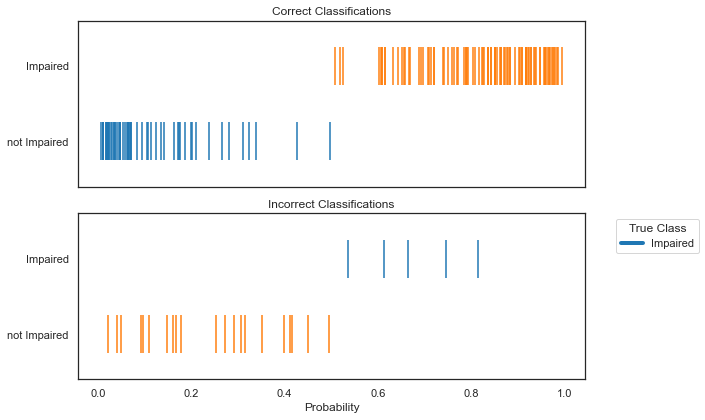

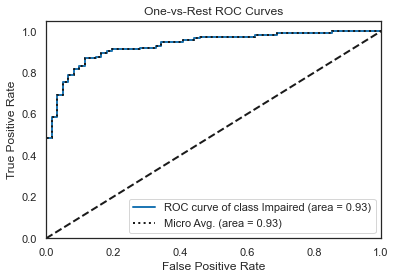

Optimal Thresholds: 
 {0: 0.352054975728776}


<Figure size 576x432 with 0 Axes>

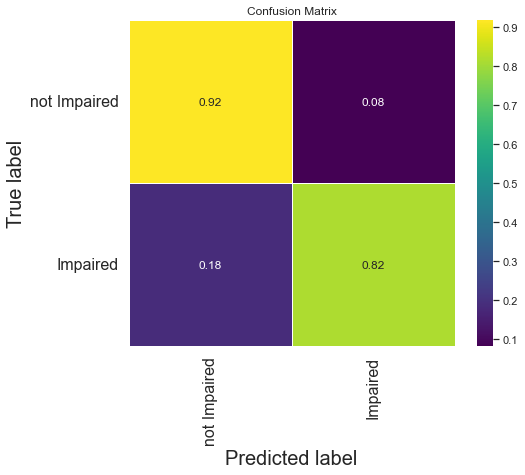

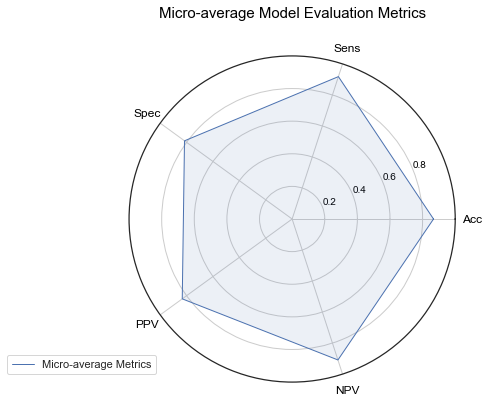

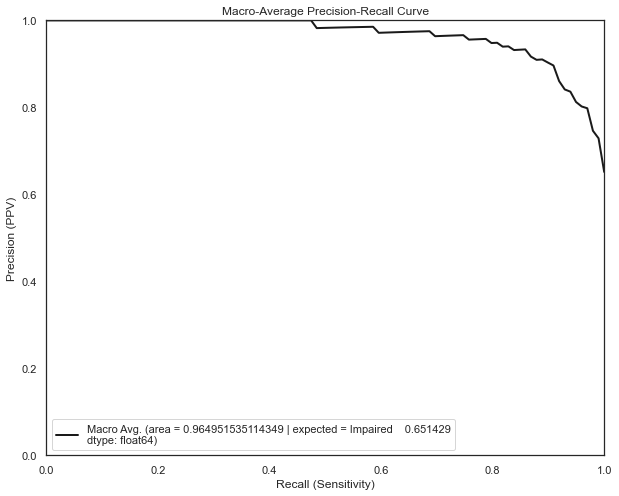

In [262]:
from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
evaluator = ComprehensiveMulticlassROC(fitted_model=results, predictions_df=None, observation_df=outcome_matrix, 
                                       normalization='true', thresholds=None, out_dir=out_dir+'/train_results')
evaluator.run()

Visuialize OVR CIs

In [263]:
df, bootstrap  = evaluator.bootstrap_ovr_auroc(raw_observations=evaluator.raw_observations, raw_predictions=evaluator.raw_predictions, outcome_matrix_cols=evaluator.outcome_matrix.columns)
ComprehensiveMulticlassROC.plot_ovr_auc_with_ci(df, out_dir=out_dir+'/train_auc_per_diagnosis')

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

ADVANCED
- code specific manual thresholds to intervene upon classifications

Step 1: relate integer (index) to class

In [234]:
# evaluator.relate_index_to_class()

Step 2: in a dictionary of the indices (corresponding to class), key in the lambda function to edit the probability. 
- Code from left to right, giving priority to each method. 
- Example:
```
>thresholds = {
>            0: lambda probs: 0 if probs[0] > 0.5 else (1 if probs[0] > 0.25 else 2),  # Adjust class_0 predictions
>            1: lambda probs: None,  # No threshold adjustment for class_1
>            2: lambda probs: None   # No threshold adjustment for class_2
>        }
```

In [235]:
# thresholds = {
#     0: lambda prob: 0,  # Always keep class 0
#     1: lambda prob: 1,  # Always keep class 1
#     2: lambda prob: 2 if prob[2] > 0.5 else (1 if prob[1] > 0.3 else 0)  # Conditional adjustment for class 2
# }


Step 3: Check the effect

In [236]:
# from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
# evaluator = ComprehensiveMulticlassROC(fitted_model=results, observation_df=outcome_matrix, normalization='pred', thresholds=thresholds, out_dir=out_dir)
# evaluator.run()

Step 4: YOU MUST LOOCV AND VALIDATE IN OUT-OF-SAMPLE DATA.
- add thresholds as an argument to any further calls to ComprehensiveMulticlassROC

Bootstrap the Micro Average AUC

In [237]:
# import matplotlib
# from calvin_utils.statistical_utils.classification_statistics import bootstrap_auc
# matplotlib.use('Agg')  # Use a non-interactive backend

# mean_auc, lower_ci, upper_ci = bootstrap_auc(outcome_matrix, design_matrix, n_iterations=1000)
# print(f'Mean AUC: {mean_auc}, 95% CI: ({lower_ci}, {upper_ci})')

Permutation Test Two Different Formulas by Comparing Their AUCs

In [238]:
data_df.columns

Index(['Unnamed__0', 'subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL',
       'CSF_Occipital', 'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal',
       'GM_Cerebellum', 'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal',
       'GM_Parietal', 'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Cohort', 'Diagnosis', 'Sex', 'Age', 'Cohort_1',
       'CTh_Cerebellum', 'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal',
       'CTh_Parietal', 'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11',
       'TOTALMOD', 'DX_BASELINE', 'Impaired', 'DX_M12', 'wm_atrophy_path',
       'gm_atrophy_path', 'fluid_atrophy_path', 'composite_atrophy_path',
       'wm_atrophy_path_smoothed', 'gm_atrophy_path_smoothed',
       'fluid_atrophy_path_smoothed', 'composite_atrophy_path_smoothed',

In [239]:
f1 = "DX_M12 ~ CSF_Cerebellum + CSF_Subcortex + CSF_MTL + CSF_Occipital + CSF_Frontal + CSF_Parietal + CSF_Temporal"
f2 = "Diagnosis ~ CTh_MTL + CTh_Occipital + CTh_Frontal + CTh_Parietal + CTh_Temporal"

In [240]:
# import matplotlib
# matplotlib.use('Agg')  # Use a non-interactive backend
# from calvin_utils.statistical_utils.classification_statistics import permute_auc_difference
# obs_diff, lower_ci, upper_ci, p_value = permute_auc_difference(data_df, formula1=f1, 
#                                                                   formula2=f2,
#                                                                   cal_palm=cal_palm, n_iterations=1000)
# print(f'Observde AUC Difference: {obs_diff}, 95% CI: ({lower_ci}, {upper_ci}), p-value: {p_value}')

# 06 - Visualize the Regression as a Forest Plot
- This will probably look poor if you ran a regression without standardizing your data. 

In [241]:
from calvin_utils.statistical_utils.statistical_measurements import MultinomialForestPlot
multinomial_forest = MultinomialForestPlot(model=results, sig_digits=2, out_dir=out_dir+'/forest_plots', table=False)
multinomial_forest.run()

AttributeError: 'LogitResults' object has no attribute 'J'

# 07 - Generate Partial Dependence Plots

In [242]:
from calvin_utils.statistical_utils.statistical_measurements import PartialDependencePlot
pdp = PartialDependencePlot(formula=formula, data_df=data_df, model=results, design_matrix=design_matrix, outcomes_df=outcome_matrix, 
                            data_range=[-100,100], out_dir=out_dir+'/partial_dep_plots', marginal_method='mean', debug=False)
pdp.run()

0:Impaired


IndexingError: Too many indexers

# 08 - Visualize the Partial Regression Plots

In [ ]:
from calvin_utils.statistical_utils.statistical_measurements import PartialRegressionPlot
partial_plot = PartialRegressionPlot(model=results, design_matrix=design_matrix, out_dir=out_dir+'/partial_regression_plot', palette=None)
partial_plot = partial_plot.run()

# 09 - LOOCV

In [ ]:
import pandas as pd
from calvin_utils.statistical_utils.logistic_regression import LogisticRegression
from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
y_true, y_pred, test_prob = LogisticRegression.run_loocv(outcome_matrix, design_matrix)
loocv_evaluator = ComprehensiveMulticlassROC(fitted_model=results, predictions_df=None, observation_df=outcome_matrix, normalization='true', thresholds=None, out_dir=out_dir+'/loocv_results')
loocv_evaluator.run()

In [ ]:
df, bootstrap  = loocv_evaluator.bootstrap_ovr_auroc(raw_observations=loocv_evaluator.raw_observations, raw_predictions=loocv_evaluator.raw_predictions, outcome_matrix_cols=loocv_evaluator.outcome_matrix.columns)
ComprehensiveMulticlassROC.plot_ovr_auc_with_ci(df, out_dir=out_dir+'/loocv_auc_per_diagnosis')

# 10 - Predict Unseen Data
- Unseen data is expected to be in a held-out CSV with the exact same naming conventions used by the training data

In [264]:
new_csv_path='/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_Atrophy/metadata/cleaned_information/master.csv'

Get New Data

In [265]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
new_palm = CalvinStatsmodelsPalm(input_csv_path=new_csv_path, output_dir=out_dir+'/test_results', sheet=sheet)
other_df = new_palm.read_and_display_data()
other_df

,Unnamed__0,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
0,3,002_S_0619,-35472.216320,-23876.106190,-1947.061673,-51088.10268,-81475.108430,-66818.857830,-72864.628840,-30069.234640,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.485236,0.580121,0.562639,0.325657,-0.243680,-0.233823,-0.233823
1,7,002_S_0816,-25421.113250,5181.427094,-602.793112,-21580.67530,-6457.362689,-10210.014380,-26903.539720,-5411.426766,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.168095,0.141948,0.143908,0.213945,-0.041915,0.003263,0.003263
2,8,002_S_0938,-8311.120182,4716.667864,-1783.156827,-17614.02943,-29354.731500,-18535.815010,-39938.858450,18816.110850,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.194173,0.256400,0.243188,0.114828,-0.288930,-0.271432,-0.271432
3,10,002_S_0955,-27460.228880,-4223.645647,-1808.785280,-42136.37844,-25613.171140,-35525.697180,-43909.671090,13848.402800,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.429159,0.500548,0.455028,0.349212,-0.255843,-0.234244,-0.234244
4,11,002_S_1018,-12574.755940,8513.644987,-94.284543,-14372.23896,-8599.629407,-15706.835180,-15822.418040,-28282.455710,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.084045,-0.126719,-0.081655,-0.016744,0.062071,0.060272,0.060272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1383,1383,941_S_4365,-38529.962160,-15404.929680,-662.636580,-45763.00179,-51966.135180,-50434.470830,-48981.572530,-9171.789970,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.310430,0.430964,0.401940,0.254941,-0.294502,-0.267127,-0.267127
1384,1384,941_S_4376,-17949.114530,-104.528538,-236.251734,-30861.23091,-12256.220060,-26738.830580,-20657.277210,-21140.712780,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.086340,0.124990,0.108221,0.094331,-0.059835,-0.042427,-0.042427
1385,1385,941_S_4377,-15992.361930,8601.241440,-63.774856,-17403.78077,-5480.603967,-8570.005333,-6582.358081,8848.744873,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.049510,-0.049247,0.042858,0.033507,0.036595,0.008515,0.008515
1386,1386,941_S_4420,-16826.370250,-551.877244,-240.304833,-19856.34299,-43372.373360,-24995.432550,-31441.476020,-5076.530307,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.135876,0.188406,0.184488,0.072262,-0.101295,-0.097994,-0.097994


Remove Nans

In [266]:
other_df = new_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(other_df)

,Unnamed__0,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
0,3,002_S_0619,-35472.216320,-23876.106190,-1947.061673,-51088.102680,-81475.108430,-66818.85783,-72864.62884,-30069.234640,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.485236,0.580121,0.562639,0.325657,-0.243680,-0.233823,-0.233823
1,7,002_S_0816,-25421.113250,5181.427094,-602.793112,-21580.675300,-6457.362689,-10210.01438,-26903.53972,-5411.426766,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.168095,0.141948,0.143908,0.213945,-0.041915,0.003263,0.003263
2,8,002_S_0938,-8311.120182,4716.667864,-1783.156827,-17614.029430,-29354.731500,-18535.81501,-39938.85845,18816.110850,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.194173,0.256400,0.243188,0.114828,-0.288930,-0.271432,-0.271432
3,10,002_S_0955,-27460.228880,-4223.645647,-1808.785280,-42136.378440,-25613.171140,-35525.69718,-43909.67109,13848.402800,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.429159,0.500548,0.455028,0.349212,-0.255843,-0.234244,-0.234244
4,11,002_S_1018,-12574.755940,8513.644987,-94.284543,-14372.238960,-8599.629407,-15706.83518,-15822.41804,-28282.455710,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.084045,-0.126719,-0.081655,-0.016744,0.062071,0.060272,0.060272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,1369,941_S_1194,-43123.686440,-4972.709606,-988.445720,-47018.922950,-46201.542160,-47286.37907,-49312.79164,-26890.827060,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.294299,0.407703,0.416110,0.302176,-0.306830,-0.285316,-0.285316
815,1370,941_S_1195,-36448.567900,-2958.680479,-1049.363458,-43300.075180,-43631.846090,-36353.42938,-51679.80762,5137.203872,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.274190,0.387713,0.362847,0.290846,-0.343612,-0.310198,-0.310198
816,1371,941_S_1197,-13872.558410,4601.684568,-458.421924,-16817.122550,-21263.165420,-23822.89374,-23093.12069,4174.322515,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.112878,0.164950,0.206002,0.069242,-0.125018,-0.135883,-0.135883
817,1372,941_S_1202,-26352.604880,-735.110333,-561.225070,-9934.943656,-33858.185030,-19699.73335,-23136.85671,-43373.920500,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.117192,0.163062,0.192889,0.151485,-0.022692,-0.049841,-0.049841


In [267]:
data_df.columns

Index(['Unnamed__0', 'subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL',
       'CSF_Occipital', 'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal',
       'GM_Cerebellum', 'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal',
       'GM_Parietal', 'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Cohort', 'Diagnosis', 'Sex', 'Age', 'Cohort_1',
       'CTh_Cerebellum', 'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal',
       'CTh_Parietal', 'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11',
       'TOTALMOD', 'DX_BASELINE', 'Impaired', 'DX_M12', 'wm_atrophy_path',
       'gm_atrophy_path', 'fluid_atrophy_path', 'composite_atrophy_path',
       'wm_atrophy_path_smoothed', 'gm_atrophy_path_smoothed',
       'fluid_atrophy_path_smoothed', 'composite_atrophy_path_smoothed',

Drop specific columns

In [268]:
column = 'Cohort'  # The column you'd like to evaluate
condition = 'equal'  # The condition to check ('equal', 'above', 'below', 'not')
value = 'Discovery' # The value to drop if found

In [269]:
other_df, _ = new_palm.drop_rows_based_on_value(column, condition, value)
display(other_df)

,Unnamed__0,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
0,3,002_S_0619,-35472.216320,-23876.106190,-1947.061673,-51088.10268,-81475.108430,-66818.85783,-72864.62884,-30069.234640,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.485236,0.580121,0.562639,0.325657,-0.243680,-0.233823,-0.233823
3,10,002_S_0955,-27460.228880,-4223.645647,-1808.785280,-42136.37844,-25613.171140,-35525.69718,-43909.67109,13848.402800,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.429159,0.500548,0.455028,0.349212,-0.255843,-0.234244,-0.234244
4,11,002_S_1018,-12574.755940,8513.644987,-94.284543,-14372.23896,-8599.629407,-15706.83518,-15822.41804,-28282.455710,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.084045,-0.126719,-0.081655,-0.016744,0.062071,0.060272,0.060272
5,40,003_S_1059,-24108.470640,-10781.314700,-1600.680328,-32977.62286,-33980.868420,-42764.54727,-43597.03495,16817.200220,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.418347,0.496969,0.493348,0.321735,-0.246773,-0.230750,-0.230750
6,43,003_S_1257,-39850.785370,-51587.474810,-4405.871162,-56695.38195,-59945.585440,-57934.72615,-75261.59588,-21115.447460,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.529845,0.591026,0.513769,0.355453,-0.140255,-0.116682,-0.116682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,1337,141_S_1094,-24741.880940,-8408.651571,-530.688781,-17999.61598,-26110.014460,-22533.06962,-29703.65525,-41469.027770,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.282184,0.288789,0.226690,0.165027,0.097053,0.101970,0.101970
814,1369,941_S_1194,-43123.686440,-4972.709606,-988.445720,-47018.92295,-46201.542160,-47286.37907,-49312.79164,-26890.827060,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.294299,0.407703,0.416110,0.302176,-0.306830,-0.285316,-0.285316
815,1370,941_S_1195,-36448.567900,-2958.680479,-1049.363458,-43300.07518,-43631.846090,-36353.42938,-51679.80762,5137.203872,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.274190,0.387713,0.362847,0.290846,-0.343612,-0.310198,-0.310198
816,1371,941_S_1197,-13872.558410,4601.684568,-458.421924,-16817.12255,-21263.165420,-23822.89374,-23093.12069,4174.322515,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.112878,0.164950,0.206002,0.069242,-0.125018,-0.135883,-0.135883


Standardize

In [270]:
other_df = new_palm.standardize_columns(cols_not_to_standardize)
other_df

Unable to standardize column Cohort.
Unable to standardize column Diagnosis.
Unable to standardize column DX_M12.
Unable to standardize column wm_atrophy_path.
Unable to standardize column gm_atrophy_path.
Unable to standardize column fluid_atrophy_path.
Unable to standardize column composite_atrophy_path.
Unable to standardize column wm_atrophy_path_smoothed.
Unable to standardize column gm_atrophy_path_smoothed.
Unable to standardize column fluid_atrophy_path_smoothed.
Unable to standardize column composite_atrophy_path_smoothed.


,Unnamed__0,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,...,gm_atrophy_path_smoothed,fluid_atrophy_path_smoothed,composite_atrophy_path_smoothed,spatial_correlation_CSF_AD,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN,cosine_GM_AD,cosine_GM_MCI,cosine_GM_CN
0,-2.149346,002_S_0619,-1.347436,-2.259723,-1.494535,-2.364716,-2.686491,-2.557124,-2.397960,-1.037837,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,1.779611,1.687997,1.800296,1.457327,-1.037793,-1.086326,-1.086326
3,-2.129560,002_S_0955,-0.569365,-0.214169,-1.317662,-1.576694,0.142623,-0.506134,-0.658011,1.413375,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,1.475358,1.345770,1.290878,1.639045,-1.121548,-1.089369,-1.089369
4,-2.126734,002_S_1018,0.876212,1.111610,0.875413,0.867389,1.004270,0.792818,1.029795,-0.938110,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-1.309122,-1.351978,-1.249701,-1.184110,1.067532,1.041189,1.041189
5,-2.044764,003_S_1059,-0.243865,-0.896733,-1.051468,-0.770446,-0.281157,-0.980577,-0.639225,1.579075,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,1.416695,1.330381,1.472279,1.427073,-1.059093,-1.064092,-1.064092
6,-2.036284,003_S_1257,-1.772653,-5.144100,-4.639680,-2.858326,-1.596134,-1.974848,-2.541998,-0.538092,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,2.021647,1.734899,1.568953,1.687184,-0.325638,-0.238911,-0.238911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,1.621257,141_S_1094,-0.305377,-0.649771,0.317194,0.548071,0.117461,0.345418,0.195650,-1.674103,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.677919,0.435041,0.209960,0.218149,1.308405,1.342832,1.342832
814,1.711706,941_S_1194,-2.090495,-0.292136,-0.268338,-2.006505,-0.900070,-1.276943,-0.982693,-0.860438,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.743652,0.946462,1.106646,1.276181,-1.472625,-1.458826,-1.458826
815,1.714533,941_S_1195,-1.442252,-0.082503,-0.346260,-1.679134,-0.769928,-0.560385,-1.124931,0.927169,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,0.634544,0.860492,0.854510,1.188776,-1.725897,-1.638826,-1.638826
816,1.717360,941_S_1197,0.750179,0.704429,0.409633,0.652166,0.362928,0.260882,0.592888,0.873427,...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_At...,-0.240680,-0.097567,0.112024,-0.520777,-0.220716,-0.377818,-0.377818


Ordinalize

In [271]:
from calvin_utils.file_utils.dataframe_utilities import convert_to_ordinal
other_df, new_map = convert_to_ordinal(other_df, ['DX_BASELINE'])

Mapping of unique values to ordinal values:
DX_BASELINE: {'Alzheimer': 0, 'MCI': 1, 'Normal': 2}


Prepare Data

In [272]:
import pandas as pd
other_outcome_matrix, other_design_matrix = new_palm.define_design_matrix(formula, other_df, add_intercept=True)

other_design_matrix

,cosine_CSF_AD,cosine_CSF_MCI,cosine_CSF_CN
0,1.687997,1.800296,1.457327
3,1.345770,1.290878,1.639045
4,-1.351978,-1.249701,-1.184110
5,1.330381,1.472279,1.427073
6,1.734899,1.568953,1.687184
...,...,...,...
813,0.435041,0.209960,0.218149
814,0.946462,1.106646,1.276181
815,0.860492,0.854510,1.188776
816,-0.097567,0.112024,-0.520777


Predict

In [273]:
choice = 'Logistic'

In [274]:
predictions_df = results.predict(other_design_matrix)

In [275]:
# thresholds = {
#     0: lambda prob: 0 if prob < 0.33 else 1,
#     1: lambda prob: 1 if prob > 0.33 else 0
# }

Taking maximum probability as prediction.
There are 476 observations for Impaired


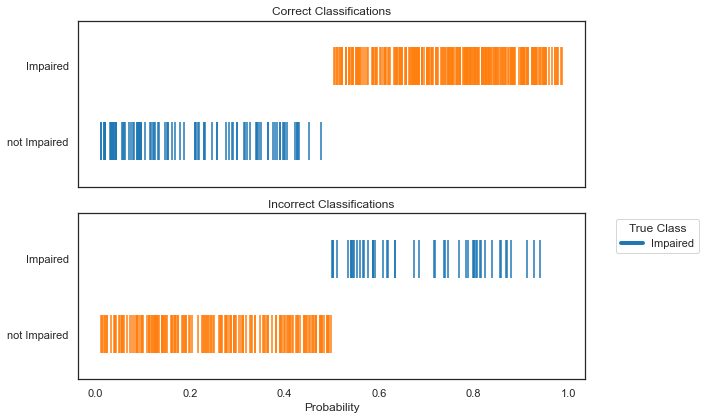

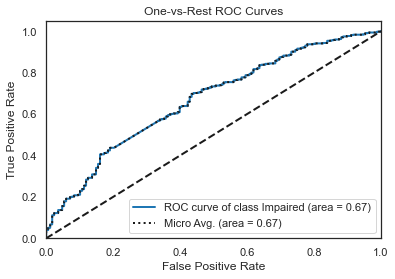

Optimal Thresholds: 
 {0: 0.4326002870811402}


<Figure size 576x432 with 0 Axes>

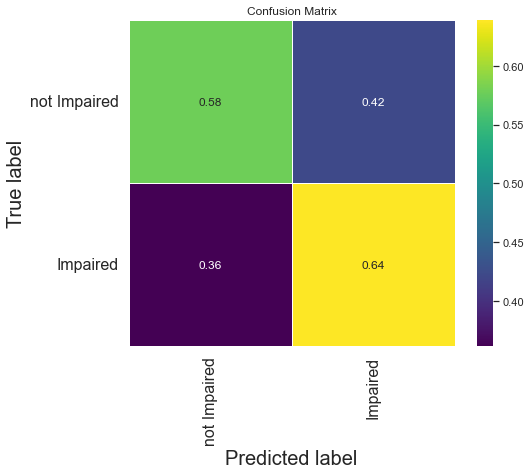

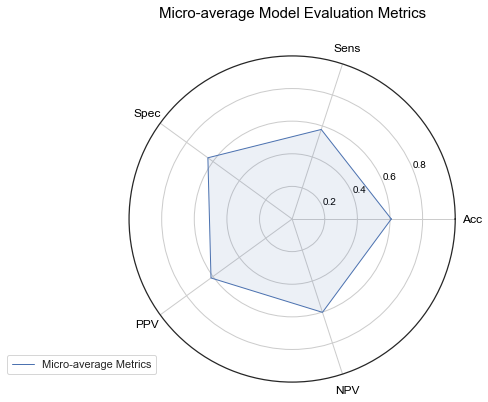

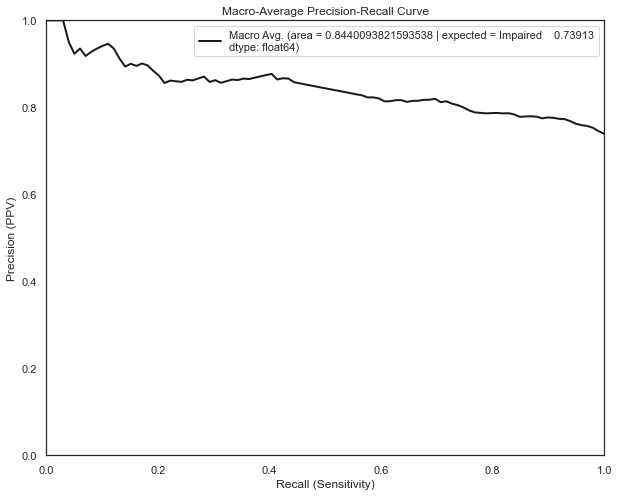

In [276]:
from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
loocv_evaluator = ComprehensiveMulticlassROC(fitted_model=None, predictions_df=predictions_df, observation_df=other_outcome_matrix, normalization='true', thresholds=None, out_dir=out_dir+'/test_results')
loocv_evaluator.run() 

In [119]:
loocv_evaluator.save_dataframes()

Saved predicted probabilities to CSV files at:  /Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_diagnostic/voxelwise/composite/avg_maps/csf/classification/test_results as predicted_probabilities.csv
and
Saved observed labels to CSV files at:  /Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_diagnostic/voxelwise/composite/avg_maps/csf/classification/test_results as observed_labels.csv


Get One Vs. All Confidence Intervals on AUC

In [ ]:
df, bootstrap = ComprehensiveMulticlassROC.bootstrap_ovr_auroc(raw_observations=loocv_evaluator.raw_observations, raw_predictions=loocv_evaluator.raw_predictions, outcome_matrix_cols=loocv_evaluator.outcome_matrix.columns)
ComprehensiveMulticlassROC.plot_ovr_auc_with_ci(df, out_dir=out_dir+'/test_auc_per_diagnosis')

In [ ]:
display(df)

Get Confidence Intervals on Sensitivity, Specificity, NPV, PPV, and Accuracy for Each Class

In [ ]:
from calvin_utils.statistical_utils.classification_statistics import calculate_youden_and_metrics, save_dfs
dfs, youden_dict = calculate_youden_and_metrics(raw_observations=loocv_evaluator.raw_observations, 
                                                raw_predictions=loocv_evaluator.raw_predictions, 
                                                outcome_matrix_cols=loocv_evaluator.outcome_matrix.columns,
                                                out_dir=out_dir+'/metrics_per_diagnosis')
save_dfs(dfs, out_dir=out_dir+'/metrics_per_diagnosis')

In [ ]:
ComprehensiveMulticlassROC.generate_all_plots(dfs, out_dir=out_dir+'/metrics_per_diagnosis')

Get Overall Micro Average AUC

In [ ]:
loocv_evaluator.get_micro_auc()

That's all

-Calvin